# Synthetic Library: Full Example

In [14]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from synthetic import Builder, make_dataset_drug_response

# Publication-ready figure configuration
FONT_SIZE = 10
MM_TO_INCHES = 1 / 25.4

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.titlesize'] = FONT_SIZE
plt.rcParams['axes.labelsize'] = FONT_SIZE
plt.rcParams['xtick.labelsize'] = FONT_SIZE
plt.rcParams['ytick.labelsize'] = FONT_SIZE
plt.rcParams['legend.fontsize'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.major.width'] = 0.8
plt.rcParams['ytick.major.width'] = 0.8
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['ytick.major.size'] = 3


In [15]:

# Create a hierarchical network with 3 degrees
vc = Builder.specify(
    degree_cascades=[2, 3, 4],
    random_seed=42,
    auto_drug=True
)

vc.compile()

print(f"Model created with {len(vc.spec.species_list)} species")
print(f"Drug: {vc.list_drugs()[0]['name']}")

Model created with 20 species
Drug: D


## Network Topology Visualization

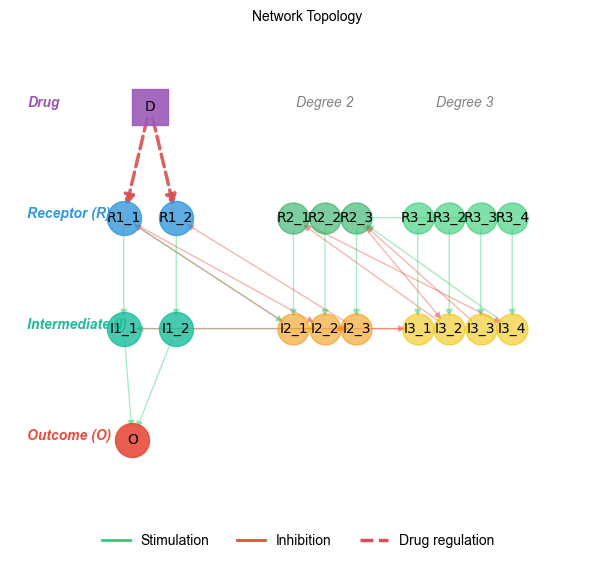

In [16]:
spec = vc.spec
G = nx.DiGraph()

# Get drug info
drugs_info = vc.list_drugs()
drug_targets = drugs_info[0]['targets'] if drugs_info else []
drug_name = drugs_info[0]['name'] if drugs_info else 'D'

# all species (including O and Oa, excluding drug)
all_species = [s for s in spec.species_list if not s.startswith('D')]
for s in all_species:
    if s in ['O', 'Oa']:
        G.add_node(s, node_type='outcome')
    elif s.startswith('R1'):
        G.add_node(s, node_type='R1')
    elif s.startswith('I1'):
        G.add_node(s, node_type='I1')
    elif s.startswith('R2'):
        G.add_node(s, node_type='R2')
    elif s.startswith('R3'):
        G.add_node(s, node_type='R3')
    elif s.startswith('I2'):
        G.add_node(s, node_type='I2')
    elif s.startswith('I3'):
        G.add_node(s, node_type='I3')
    else:
        G.add_node(s, node_type='species')

# Add drug node
G.add_node(drug_name, node_type='drug')

# Add species-to-species regulations
for reg in spec.regulations:
    from_spec = reg.from_specie
    to_spec = reg.to_specie
    if from_spec in all_species and to_spec in all_species:
        color = '#2ecc71' if reg.reg_type == 'up' else '#e74c3c'
        G.add_edge(from_spec, to_spec, color=color, edge_type='regulation')

# Add drug-to-target edges
for target in drug_targets:
    if target in all_species:
        G.add_edge(drug_name, target, color='#9b59b6', edge_type='drug')

fig_width_mm = 195
fig_height_mm = 155
fig, ax = plt.subplots(figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

# Create hierarchical layout: D -> R1 -> I1 -> O (vertical), Degree 2 and 3 horizontal with gap
def get_position(node):
    """Assign positions: D -> R -> I -> O (vertical), Degree 2 and 3 horizontal with gap."""
    if node == drug_name:
        return (0, 4)
    elif node.startswith('R1'):
        r1_nodes = sorted([n for n in G.nodes() if n.startswith('R1')])
        idx = r1_nodes.index(node)
        n = len(r1_nodes)
        x = (idx - (n - 1) / 2) * 1.5
        return (x, 3)
    elif node.startswith('I1'):
        i1_nodes = sorted([n for n in G.nodes() if n.startswith('I1')])
        idx = i1_nodes.index(node)
        n = len(i1_nodes)
        x = (idx - (n - 1) / 2) * 1.5
        return (x, 2)
    elif node in ['O', 'Oa']:
        offset = 0.5 if node == 'Oa' else -0.5
        return (offset, 1)
    elif node.startswith('R2'):
        r2_nodes = sorted([n for n in G.nodes() if n.startswith('R2')])
        idx = r2_nodes.index(node)
        n = len(r2_nodes)
        x = 5 + (idx - (n - 1) / 2) * 0.9
        return (x, 3)
    elif node.startswith('R3'):
        r3_nodes = sorted([n for n in G.nodes() if n.startswith('R3')])
        idx = r3_nodes.index(node)
        n = len(r3_nodes)
        x = 9 + (idx - (n - 1) / 2) * 0.9
        return (x, 3)
    elif node.startswith('I2'):
        i2_nodes = sorted([n for n in G.nodes() if n.startswith('I2')])
        idx = i2_nodes.index(node)
        n = len(i2_nodes)
        x = 5 + (idx - (n - 1) / 2) * 0.9
        return (x, 2)
    elif node.startswith('I3'):
        i3_nodes = sorted([n for n in G.nodes() if n.startswith('I3')])
        idx = i3_nodes.index(node)
        n = len(i3_nodes)
        x = 9 + (idx - (n - 1) / 2) * 0.9
        return (x, 2)
    else:
        return (3, 2.5)

pos = {node: get_position(node) for node in G.nodes()}

# Draw species-to-species edges
for color in ['#2ecc71', '#e74c3c']:
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('color') == color]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=color,
                           arrowsize=10, width=1.0, alpha=0.4, ax=ax)

# Draw drug edges (highlighted)
drug_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'drug']
nx.draw_networkx_edges(G, pos, edgelist=drug_edges, edge_color="#d65151",
                       arrowsize=15, width=2.5, alpha=0.9, style='dashed', ax=ax)

# Draw nodes by type
r1_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'R1']
nx.draw_networkx_nodes(G, pos, nodelist=r1_nodes, node_color='#3498db', 
                       node_size=600, alpha=0.8, ax=ax)

i1_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'I1']
nx.draw_networkx_nodes(G, pos, nodelist=i1_nodes, node_color='#1abc9c', 
                       node_size=600, alpha=0.8, ax=ax)

r2_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'R2']
nx.draw_networkx_nodes(G, pos, nodelist=r2_nodes, node_color='#27ae60', 
                       node_size=500, alpha=0.6, ax=ax)

r3_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'R3']
nx.draw_networkx_nodes(G, pos, nodelist=r3_nodes, node_color='#2ecc71', 
                       node_size=500, alpha=0.6, ax=ax)

i2_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'I2']
nx.draw_networkx_nodes(G, pos, nodelist=i2_nodes, node_color='#f39c12', 
                       node_size=500, alpha=0.6, ax=ax)

i3_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'I3']
nx.draw_networkx_nodes(G, pos, nodelist=i3_nodes, node_color='#f1c40f', 
                       node_size=500, alpha=0.6, ax=ax)

outcome_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'outcome']
nx.draw_networkx_nodes(G, pos, nodelist=outcome_nodes, node_color='#e74c3c', 
                       node_size=600, alpha=0.9, ax=ax)

drug_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'drug']
nx.draw_networkx_nodes(G, pos, nodelist=drug_nodes, node_color='#9b59b6', 
                       node_size=700, alpha=0.9, node_shape='s', ax=ax)

nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

# Add layer labels on the left
ax.text(-3.5, 4, 'Drug', fontsize=10, ha='left', style='italic', color='#9b59b6', fontweight='bold')
ax.text(-3.5, 3, 'Receptor (R)', fontsize=10, ha='left', style='italic', color='#3498db', fontweight='bold')
ax.text(-3.5, 2, 'Intermediate (I)', fontsize=10, ha='left', style='italic', color='#1abc9c', fontweight='bold')
ax.text(-3.5, 1, 'Outcome (O)', fontsize=10, ha='left', style='italic', color='#e74c3c', fontweight='bold')

# Add horizontal branch labels
ax.text(5, 4, 'Degree 2', fontsize=10, ha='center', style='italic', color='gray')
ax.text(9, 4, 'Degree 3', fontsize=10, ha='center', style='italic', color='gray')

ax.set_title("Network Topology", fontsize=FONT_SIZE)
ax.set_xlim(-4, 13)
ax.set_ylim(0.3, 4.7)
sns.despine(left=True, bottom=True)
ax.axis('off')

# Legend at bottom of figure
fig.legend(
    handles=[
        plt.Line2D([0], [0], color='#2ecc71', lw=2, label='Stimulation'),
        plt.Line2D([0], [0], color='#e74c3c', lw=2, label='Inhibition'),
        plt.Line2D([0], [0], color='#d65151', lw=2.5, linestyle='dashed', label='Drug regulation'),
    ],
    loc='lower center', ncol=3, frameon=False, fontsize=FONT_SIZE,
    bbox_to_anchor=(0.5, 0.01),
)
fig.subplots_adjust(bottom=0.08)

plt.savefig('../docs/images/network_topology.png', dpi=200, bbox_inches='tight')
plt.show()

## Timecourse Simulation

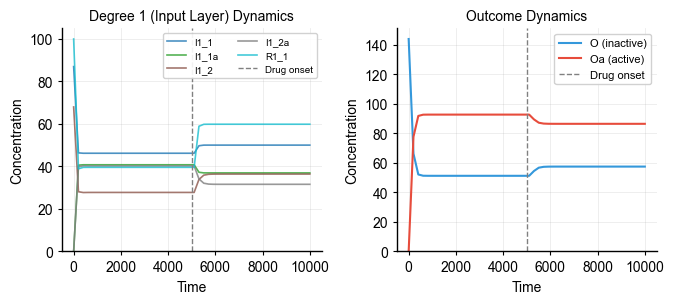

In [17]:
from synthetic.Solver.ScipySolver import ScipySolver
import warnings

antimony = vc.model.get_antimony_model()
solver = ScipySolver()
solver.compile(antimony, jit=False)

timecourse = solver.simulate(start=0, stop=10000, step=50)

fig_width_mm = 174
fig_height_mm = 80
fig, axes = plt.subplots(1, 2, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

# Sort species alphabetically for consistent ordering across solvers
degree1_species = sorted([s for s in timecourse.columns if s.startswith('R1') or s.startswith('I1')])
colors = plt.cm.tab10(np.linspace(0, 1, len(degree1_species[:5])))
for i, species in enumerate(degree1_species[:5]):
    axes[0].plot(timecourse['time'], timecourse[species], color=colors[i], alpha=0.8, linewidth=1.2, label=species)
axes[0].axvline(x=5000, color='gray', linestyle='--', linewidth=1, label='Drug onset')
axes[0].set_title('Degree 1 (Input Layer) Dynamics', fontsize=FONT_SIZE)
axes[0].set_xlabel('Time', fontsize=FONT_SIZE)
axes[0].set_ylabel('Concentration', fontsize=FONT_SIZE)
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3, linewidth=0.5)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
axes[0].legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.9)

axes[1].plot(timecourse['time'], timecourse['O'], linewidth=1.5, color='#3498db', label='O (inactive)')
axes[1].plot(timecourse['time'], timecourse['Oa'], linewidth=1.5, color='#e74c3c', label='Oa (active)')
axes[1].axvline(x=5000, color='gray', linestyle='--', linewidth=1, label='Drug onset')
axes[1].set_title('Outcome Dynamics', fontsize=FONT_SIZE)
axes[1].set_xlabel('Time', fontsize=FONT_SIZE)
axes[1].set_ylabel('Concentration', fontsize=FONT_SIZE)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3, linewidth=0.5)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)
axes[1].legend(fontsize=8, loc='best', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/timecourse_scipy.png', dpi=200, bbox_inches='tight')
plt.show()

### Using RoadrunnerSolver

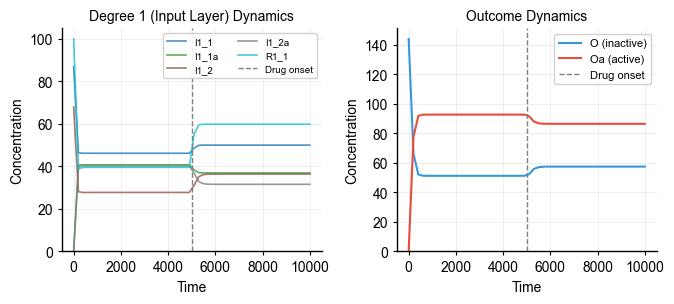

In [18]:
from synthetic.Solver.RoadrunnerSolver import RoadrunnerSolver

# RoadrunnerSolver requires SBML format (not Antimony)
sbml = vc.model.get_sbml_model()
solver = RoadrunnerSolver()
solver.compile(sbml)

timecourse = solver.simulate(start=0, stop=10000, step=50)

fig_width_mm = 174
fig_height_mm = 80
fig, axes = plt.subplots(1, 2, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

# Sort species alphabetically for consistent ordering across solvers
degree1_species = sorted([s for s in timecourse.columns if s.startswith('R1') or s.startswith('I1')])
colors = plt.cm.tab10(np.linspace(0, 1, len(degree1_species[:5])))
for i, species in enumerate(degree1_species[:5]):
    axes[0].plot(timecourse['time'], timecourse[species], color=colors[i], alpha=0.8, linewidth=1.2, label=species)
axes[0].axvline(x=5000, color='gray', linestyle='--', linewidth=1, label='Drug onset')
axes[0].set_title('Degree 1 (Input Layer) Dynamics', fontsize=FONT_SIZE)
axes[0].set_xlabel('Time', fontsize=FONT_SIZE)
axes[0].set_ylabel('Concentration', fontsize=FONT_SIZE)
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3, linewidth=0.5)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
axes[0].legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.9)

axes[1].plot(timecourse['time'], timecourse['O'], linewidth=1.5, color='#3498db', label='O (inactive)')
axes[1].plot(timecourse['time'], timecourse['Oa'], linewidth=1.5, color='#e74c3c', label='Oa (active)')
axes[1].axvline(x=5000, color='gray', linestyle='--', linewidth=1, label='Drug onset')
axes[1].set_title('Outcome Dynamics', fontsize=FONT_SIZE)
axes[1].set_xlabel('Time', fontsize=FONT_SIZE)
axes[1].set_ylabel('Concentration', fontsize=FONT_SIZE)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3, linewidth=0.5)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)
axes[1].legend(fontsize=8, loc='best', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/timecourse_roadrunner.png', dpi=200, bbox_inches='tight')
plt.show()

## Synthetic Data Generation

In [19]:
# Get extended data including timecourse
result = make_dataset_drug_response(
    n=500,
    cell_model=vc,
    target_specie="Oa",
    perturbation_type="lognormal",
    perturbation_params={"shape": 0.3},
    seed=42,
    return_timecourse=True,  # Returns dictionary with X, y, timecourse, parameters, metadata
)

# Access the data
X = result["X"]  # Feature matrix (initial values)
y = result["y"]  # Target values
timecourse = result["timecourse"]  # Timecourse data for all species
parameters = result["parameters"]  # Kinetic parameters (if perturbed)
metadata = result["metadata"]  # Generation metadata

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Timecourse samples: {len(timecourse)}")
print(f"Success rate: {metadata['success_rate']:.2%}")

X shape: (500, 18)
y shape: (500,)
Timecourse samples: 500
Success rate: 100.00%


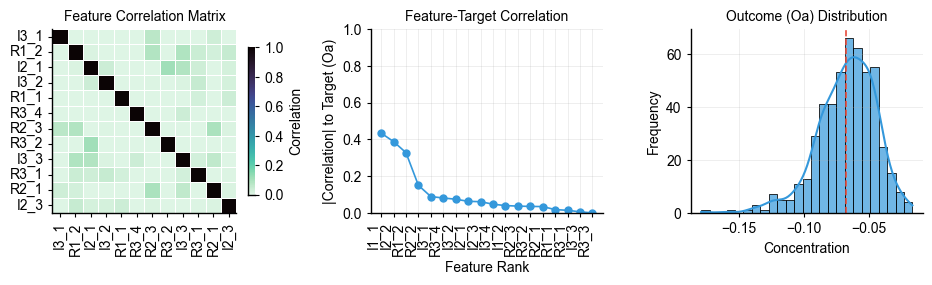

In [20]:
fig_width_mm = 240
fig_height_mm = 75
fig, axes = plt.subplots(1, 3, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

FONT_SIZE = 10

# 1. Feature correlation heatmap (clean matrix without NaN)
X_numeric = X.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
top_features = X_numeric.var().nlargest(min(12, X_numeric.shape[1])).index
corr_matrix = X_numeric[list(top_features)].corr().dropna(axis=0, how='all').dropna(axis=1, how='all')

# Ensure symmetric matrix with matching labels
common_features = corr_matrix.index.intersection(corr_matrix.columns)
corr_matrix = corr_matrix.loc[common_features, common_features]

sns.heatmap(corr_matrix, annot=False, cmap='mako_r', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            ax=axes[0], linewidths=0.5, xticklabels=True, yticklabels=True)
axes[0].set_title('Feature Correlation Matrix', fontsize=FONT_SIZE)
axes[0].tick_params(axis='x', labelsize=FONT_SIZE, rotation=90)
axes[0].tick_params(axis='y', labelsize=FONT_SIZE, rotation=0)
axes[0].figure.axes[-1].yaxis.label.set_size(FONT_SIZE)

# 2. Feature-target correlation (ranked by absolute value)
feature_corr = X_numeric.corrwith(y).abs().sort_values(ascending=False)
axes[1].plot(range(len(feature_corr)), feature_corr.values, 'o-', color='#3498db', linewidth=1.2, markersize=5)
axes[1].set_xlabel('Feature Rank', fontsize=FONT_SIZE)
axes[1].set_ylabel('|Correlation| to Target (Oa)', fontsize=FONT_SIZE)
axes[1].set_title('Feature-Target Correlation', fontsize=FONT_SIZE)
axes[1].set_xticks(range(len(feature_corr)))
axes[1].set_xticklabels(feature_corr.index, rotation=90, ha='right', fontsize=FONT_SIZE)
axes[1].tick_params(axis='y', labelsize=FONT_SIZE)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, linewidth=0.5)

# 3. Outcome distribution
sns.histplot(y, bins=25, kde=True, color='#3498db', ax=axes[2], alpha=0.7)
axes[2].axvline(y.mean(), color='#e74c3c', linestyle='--', linewidth=1.2)
axes[2].set_title('Outcome (Oa) Distribution', fontsize=FONT_SIZE)
axes[2].set_xlabel('Concentration', fontsize=FONT_SIZE)
axes[2].set_ylabel('Frequency', fontsize=FONT_SIZE)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)
axes[2].grid(True, alpha=0.3, linewidth=0.5)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/data_generation_feature_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary & Quick ML Demo

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

FONT_SIZE = 10
MM_TO_INCHES = 1 / 25.4

models = {
    "ElasticNet": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (RBF)": KNeighborsRegressor(),
}

# Store results
results = {'Model': [], 'Pearson r': [], 'R²': [], 'MSE': []}

print("Model Comparison (5-fold CV):\n")
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=5)
    r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    mse = mean_squared_error(y, y_pred)
    pearson_r, pearson_p = pearsonr(y, y_pred)
    
    results['Model'].append(name)
    results['Pearson r'].append(pearson_r)
    results['R²'].append(r2_scores.mean())
    results['MSE'].append(mse)
    
    print(f"{name}:")
    print(f"  R²: {r2_scores.mean():.3f} (+/- {r2_scores.std():.3f})")
    print(f"  Pearson r: {pearson_r:.3f} (p={pearson_p:.4f})")
    print(f"  MSE: {mse:.6f}\n")


Model Comparison (5-fold CV):

ElasticNet:
  R²: 0.410 (+/- 0.034)
  Pearson r: 0.648 (p=0.0000)
  MSE: 0.000292

Random Forest:
  R²: 0.361 (+/- 0.051)
  Pearson r: 0.614 (p=0.0000)
  MSE: 0.000314

SVM (RBF):
  R²: 0.064 (+/- 0.070)
  Pearson r: 0.336 (p=0.0000)
  MSE: 0.000459



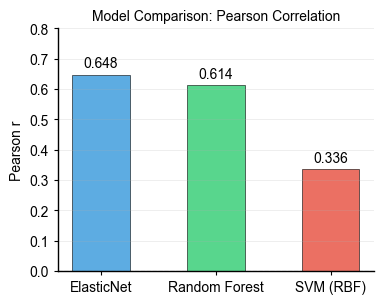

In [22]:
# Bar chart comparing Pearson r
fig, ax = plt.subplots(figsize=(100 * MM_TO_INCHES, 80 * MM_TO_INCHES))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(results['Model'], results['Pearson r'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5, width=0.5)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Pearson r', fontsize=FONT_SIZE)
ax.set_title('Model Comparison: Pearson Correlation', fontsize=FONT_SIZE)
ax.tick_params(axis='both', labelsize=FONT_SIZE)
ax.set_ylim(0, 0.8)
ax.grid(True, alpha=0.3, axis='y', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, results['Pearson r']):
    height = bar.get_height()
    ax.annotate(f'{val:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -5),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=FONT_SIZE)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/ml_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Timecourse data manupulation

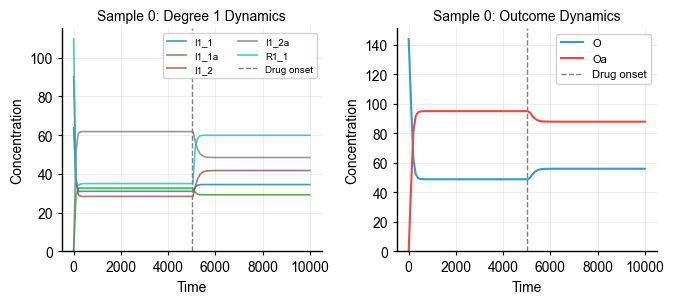

Drug start time: 5000.0
Pre-drug index: 47
Target value (y): -0.0749


In [23]:
# Timecourse data manipulation example
# The timecourse is a DataFrame where each cell contains a numpy array of timecourse values

# Get a single sample's timecourse (e.g., sample 0)
sample_idx = 0
sample_timecourse = timecourse.iloc[sample_idx]

# Extract time array from actual data length (solver may include extra change-points)
first_valid = next(v for v in sample_timecourse if v is not None)
time_array = np.linspace(
    metadata['simulation_params']['start'],
    metadata['simulation_params']['end'],
    len(first_valid)
)

# Plot timecourse for a single sample
fig_width_mm = 174
fig_height_mm = 80
fig, axes = plt.subplots(1, 2, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

# Plot degree 1 species for sample 0
degree1_cols = [col for col in sample_timecourse.index if col.startswith('R1') or col.startswith('I1')]
colors = plt.cm.tab10(np.linspace(0, 1, min(5, len(degree1_cols))))
for i, col in enumerate(sorted(degree1_cols)[:5]):
    if sample_timecourse[col] is not None:
        axes[0].plot(time_array, sample_timecourse[col], color=colors[i], alpha=0.8, linewidth=1.2, label=col)

axes[0].axvline(x=metadata['drug_start_time'], color='gray', linestyle='--', linewidth=1, label='Drug onset')
axes[0].set_title(f'Sample {sample_idx}: Degree 1 Dynamics', fontsize=FONT_SIZE)
axes[0].set_xlabel('Time', fontsize=FONT_SIZE)
axes[0].set_ylabel('Concentration', fontsize=FONT_SIZE)
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3, linewidth=0.5)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
axes[0].legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.9)

# Plot outcome species
if sample_timecourse['O'] is not None and sample_timecourse['Oa'] is not None:
    axes[1].plot(time_array, sample_timecourse['O'], linewidth=1.5, color='#3498db', label='O')
    axes[1].plot(time_array, sample_timecourse['Oa'], linewidth=1.5, color='#e74c3c', label='Oa')
axes[1].axvline(x=metadata['drug_start_time'], color='gray', linestyle='--', linewidth=1, label='Drug onset')
axes[1].set_title(f'Sample {sample_idx}: Outcome Dynamics', fontsize=FONT_SIZE)
axes[1].set_xlabel('Time', fontsize=FONT_SIZE)
axes[1].set_ylabel('Concentration', fontsize=FONT_SIZE)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3, linewidth=0.5)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)
axes[1].legend(fontsize=8, loc='best', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/timecourse_single_sample.png', dpi=200, bbox_inches='tight')
plt.show()

# Print sample info
print(f"Drug start time: {metadata['drug_start_time']}")
print(f"Pre-drug index: {metadata['pre_drug_index']}")
print(f"Target value (y): {y.iloc[sample_idx]:.4f}")

Original X features: 18 species
Timecourse last-point features: 18 species
Kinetic parameters: 93 parameters
Valid samples: 500

Performance Comparison: Initial Values vs Timecourse vs Kinetic Parameters

LinearRegression (Initial Values):
  Pearson r: 0.648, R²: 0.410, MSE: 0.000292

LinearRegression (Kinetic Parameters):
  Pearson r: 0.544, R²: 0.239, MSE: 0.000372

LinearRegression (Timecourse Last Point):
  Pearson r: 0.775, R²: 0.593, MSE: 0.000201

Random Forest (Initial Values):
  Pearson r: 0.614, R²: 0.361, MSE: 0.000314

Random Forest (Kinetic Parameters):
  Pearson r: 0.334, R²: 0.089, MSE: 0.000448

Random Forest (Timecourse Last Point):
  Pearson r: 0.770, R²: 0.581, MSE: 0.000206

KNN (Initial Values):
  Pearson r: 0.336, R²: 0.064, MSE: 0.000459

KNN (Kinetic Parameters):
  Pearson r: 0.282, R²: 0.011, MSE: 0.000486

KNN (Timecourse Last Point):
  Pearson r: 0.595, R²: 0.331, MSE: 0.000329


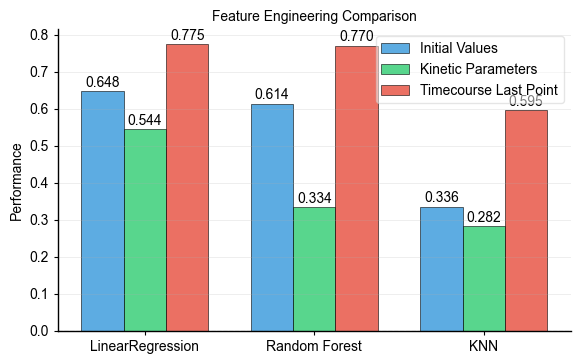

In [25]:
# Feature engineering from timecourse data
# Use the last time point of each species as features (post-drug steady state)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# Extract last point from each sample's timecourse
last_point_features = []
for idx in range(len(timecourse)):
    sample_tc = timecourse.iloc[idx]
    last_points = {}
    for col in sample_tc.index:
        if sample_tc[col] is not None:
            last_points[col] = sample_tc[col][-1]  # Last time point
        else:
            last_points[col] = np.nan
    last_point_features.append(last_points)

X_timecourse = pd.DataFrame(last_point_features, index=timecourse.index)

# Keep only activated species from timecourse features
X_timecourse = X_timecourse[[col for col in X_timecourse.columns if col.endswith('a')]]

# Drop outcome to avoid target leakage
X_timecourse = X_timecourse.drop(columns=['Oa'], errors='ignore')

# Get kinetic parameters
X_params = parameters.copy()

# Drop any NaN rows for fair comparison across all datasets
valid_mask = ~(X_timecourse.isna().any(axis=1) | y.isna() | parameters.isna().any(axis=1))
X_tc_clean = X_timecourse[valid_mask]
X_clean = X[valid_mask]
X_params_clean = X_params[valid_mask]
y_clean = y[valid_mask]

print(f"Original X features: {X_clean.shape[1]} species")
print(f"Timecourse last-point features: {X_tc_clean.shape[1]} species")
print(f"Kinetic parameters: {X_params_clean.shape[1]} parameters")
print(f"Valid samples: {len(y_clean)}")

# Model factory function to create fresh instances
def get_model(name):
    """Create a fresh model instance."""
    if name == "LinearRegression":
        return LinearRegression()
    elif name == "Random Forest":
        return RandomForestRegressor(n_estimators=100, random_state=42)
    elif name == "KNN":
        return KNeighborsRegressor()
    else:
        raise ValueError(f"Unknown model: {name}")

model_names = ["LinearRegression", "Random Forest", "KNN"]
feature_sets = [
    ('Initial Values', X_clean, '#3498db'),
    ('Kinetic Parameters', X_params_clean, '#2ecc71'),
    ('Timecourse Last Point', X_tc_clean, '#e74c3c'),
]

results_comparison = {'Model': [], 'Feature Type': [], 'Pearson r': [], 'R²': [], 'MSE': []}

print("\n" + "="*60)
print("Performance Comparison: Initial Values vs Timecourse vs Kinetic Parameters")
print("="*60)

for name in model_names:
    for feature_name, X_data, _ in feature_sets:
        # Create fresh model instance for each feature type
        model = get_model(name)
        y_pred = cross_val_predict(model, X_data, y_clean, cv=5)
        r2_scores = cross_val_score(model, X_data, y_clean, cv=5, scoring='r2')
        mse = mean_squared_error(y_clean, y_pred)
        pearson_r, _ = pearsonr(y_clean, y_pred)
        
        results_comparison['Model'].append(name)
        results_comparison['Feature Type'].append(feature_name)
        results_comparison['Pearson r'].append(pearson_r)
        results_comparison['R²'].append(r2_scores.mean())
        results_comparison['MSE'].append(mse)
        
        print(f"\n{name} ({feature_name}):")
        print(f"  Pearson r: {pearson_r:.3f}, R²: {r2_scores.mean():.3f}, MSE: {mse:.6f}")

# Bar chart comparison
comparison_df = pd.DataFrame(results_comparison)
fig, ax = plt.subplots(figsize=(150 * MM_TO_INCHES, 95 * MM_TO_INCHES))

x_pos = np.arange(len(model_names))
width = 0.25
n_features = len(feature_sets)

for i, (feature_name, _, color) in enumerate(feature_sets):
    subset = comparison_df[comparison_df['Feature Type'] == feature_name]
    offset = width * (i - (n_features - 1) / 2)
    bars = ax.bar(x_pos + offset, subset['Pearson r'].values, width, 
                  color=color, alpha=0.8, edgecolor='black', linewidth=0.5,
                  label=feature_name)
    
    for bar, val in zip(bars, subset['Pearson r'].values):
        ax.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=FONT_SIZE)

ax.set_ylabel('Performance', fontsize=FONT_SIZE)
ax.set_title('Feature Engineering Comparison', fontsize=FONT_SIZE)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=FONT_SIZE)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y', linewidth=0.5)
ax.legend(fontsize=FONT_SIZE, loc='upper right', framealpha=0.5)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/feature_engineering_comparison.png', dpi=200, bbox_inches='tight')
plt.show()